In [1]:
from dataclasses import replace
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Markdown, display

from data.share_data import load_share_data
from scripts.madrl import SCHEMES, plot_madrl_outputs, run_madrl_scheme_experiment
from utils.run_artifacts import load_experiment_context


In [2]:
run_dir = Path("artifacts/runs/20260504_234339_01e73bd1")
scheme_name = "madrl_projection_safe"
cfg, run_dir = load_experiment_context(run_dir)
cfg = replace(cfg, obs=replace(cfg.obs, sequence_length=49))
share_data = load_share_data(run_dir / "share_data", cfg)
assert int(share_data.manifest["sequence_length"]) == int(cfg.obs.sequence_length)
spec = next(item for item in SCHEMES if item["scheme"] == scheme_name)
train_episodes = 500
w_voltage, w_line, w_trafo = spec["reward"]

display(Markdown("# MADRL + Safety Projection + LSTM Forecast"))
display(pd.DataFrame([{
    "run_dir": str(run_dir),
    "scheme": scheme_name,
    "controller": spec["controller"],
    "train_episodes": train_episodes,
    "device": cfg.runtime.device,
    "train_window_days": int(cfg.env.train_window_days),
    "train_episode_steps": int(cfg.env.episode_steps) * int(cfg.env.train_window_days),
    "action_dim": int(cfg.model.action_dim),
    "max_charge_rate": float(cfg.env.max_charge_rate),
    "init_soc": float(cfg.env.init_soc),
    "train_init_soc_low": float(cfg.env.train_init_soc_low),
    "train_init_soc_high": float(cfg.env.train_init_soc_high),
    "batch_size": int(cfg.train.batch_size),
    "gamma": float(cfg.algo.gamma),
    "tau": float(cfg.algo.tau),
    "hidden_dim": int(cfg.model.hidden_dim),
    "n_step_return": int(cfg.train.n_step_return),
    "w_voltage_pen": float(w_voltage),
    "w_line_pen": float(w_line),
    "w_trafo_pen": float(w_trafo),
}]))


# MADRL + Safety Projection + LSTM Forecast

,run_dir,scheme,controller,train_episodes,device,train_window_days,train_episode_steps,action_dim,max_charge_rate,init_soc,train_init_soc_low,train_init_soc_high,batch_size,gamma,tau,hidden_dim,n_step_return,w_voltage_pen,w_line_pen,w_trafo_pen
0,artifacts\runs\20260504_234339_01e73bd1,madrl_projection_safe,MADRL_PROJECTION,500,cuda,7,672,2,0.5,0.05,0.05,0.05,512,0.999,0.01,256,96,400.0,0.0,10.0


In [3]:
result = run_madrl_scheme_experiment(cfg, run_dir, share_data, spec, episodes=train_episodes)

display(Markdown("## Train Summary"))
display(result["train_summary"])

saved = result["records"][scheme_name]
display(Markdown("## Test Metrics"))
display(saved["metrics_df"])
display(Markdown("## Agent Summary"))
display(saved["rollout"].summary)
pprint({"record_dir": str(saved["record_dir"])})


train madrl_projection_safe:   0%|          | 0/500 [00:00<?, ?episode/s]

MADRL + Safety Projection + LSTM Forecast/lstm:   0%|          | 0/15 [00:00<?, ?episode/s]

## Train Summary

,scheme,controller,label,algo,projection,episodes,steps,updates,elapsed_s,vec_env_kind,...,action_sample_s,env_step_s,replay_add_s,sample_update_s,other_s,batch_size,num_envs,parallel_episode_sampling,model_path,record_dir
0,madrl_projection_safe,MADRL_PROJECTION,MADRL + Safety Projection + LSTM Forecast,MATD3_SAFE_POC,True,500,336000,82657,9983.572708,subproc,...,977.021508,1844.208006,39.734226,7107.817349,14.791618,512,4,unique_active,artifacts\runs\20260504_234339_01e73bd1\models...,artifacts\runs\20260504_234339_01e73bd1\result...


## Test Metrics

...

{

'record_dir'

: 

'artifacts\\runs\\20260504_234339_01e73bd1\\results\\lstm\\MADRL_PROJECTION\\record'

}

C:\Users\10856\Desktop\GithubProject\MADRL_ESS\utils\records.py:392: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=[], labels=[], loc="upper right")


1. 电力电量平衡

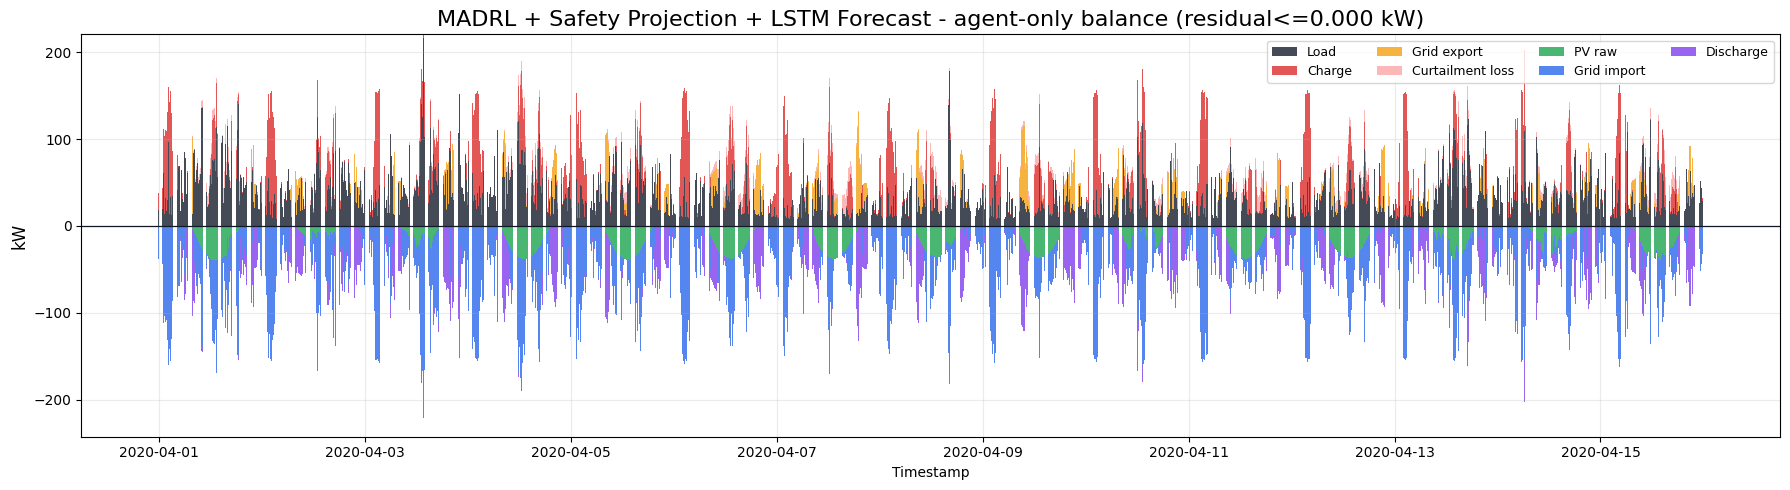

2. 电价

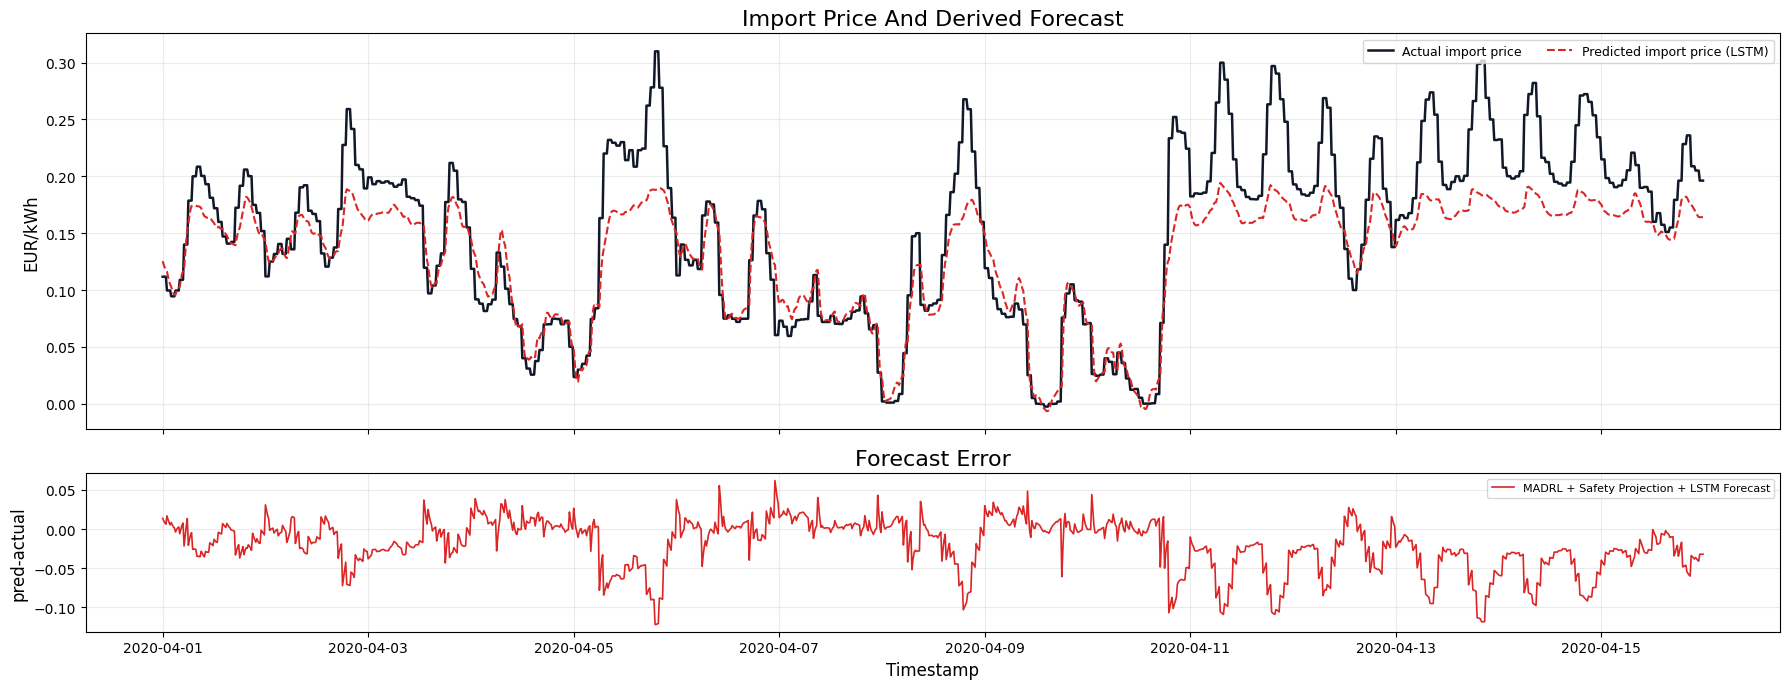

3. 总体储能充放功率与 SoC

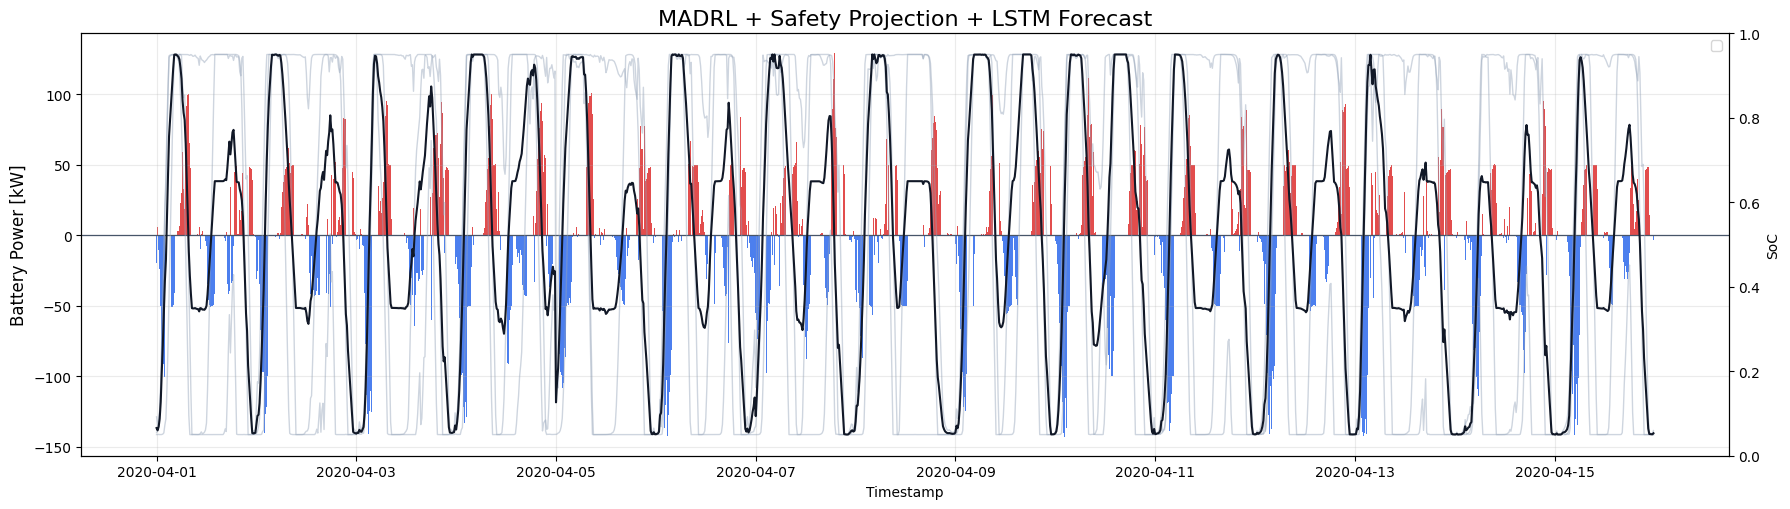

4. 电压

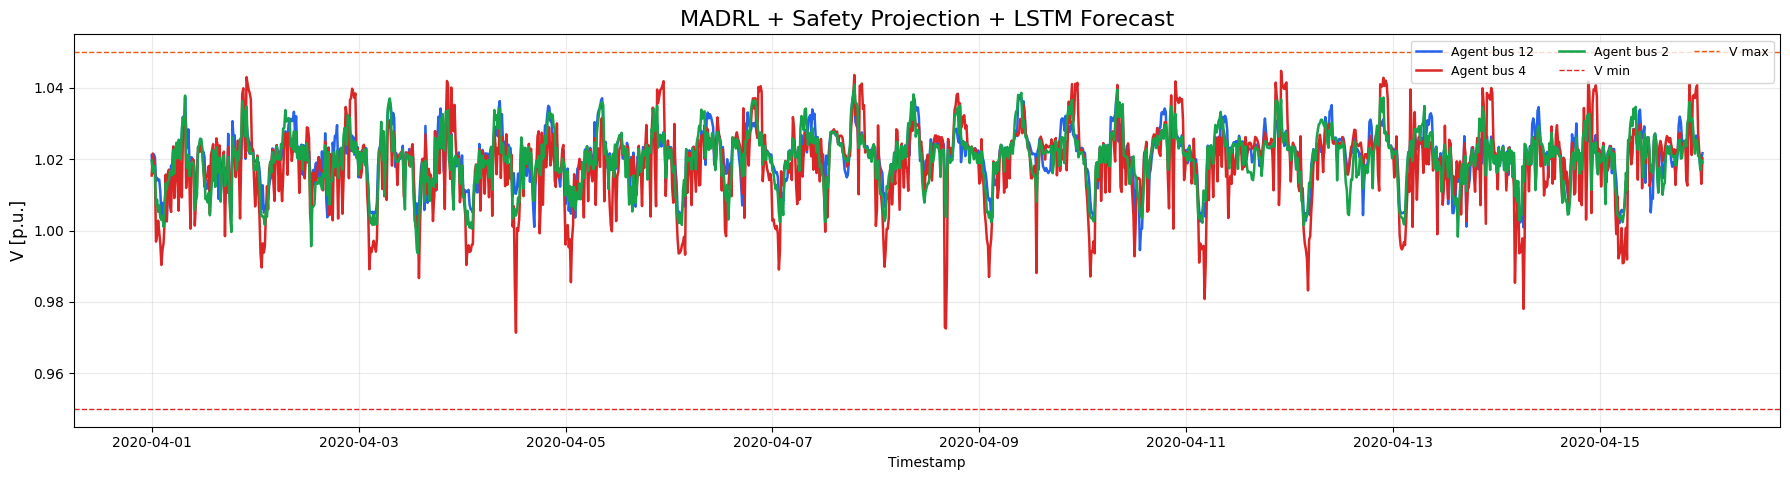

5. 净负荷

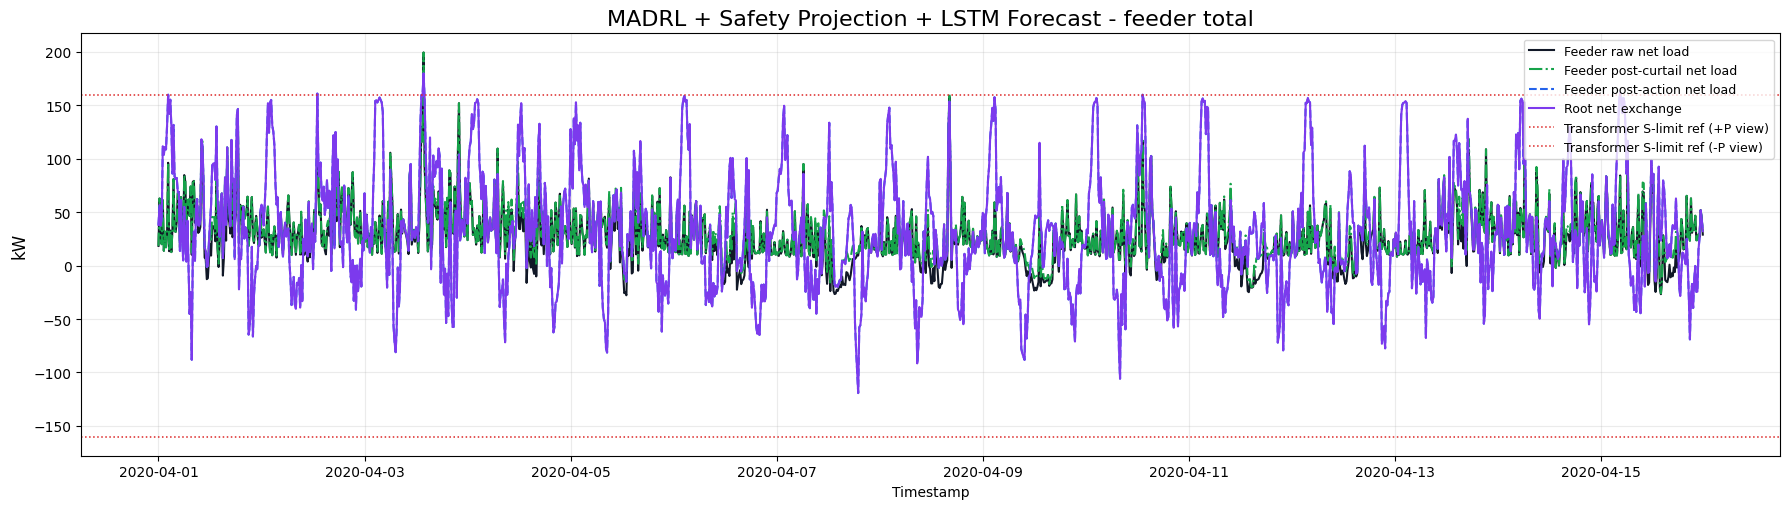

6. 训练奖励

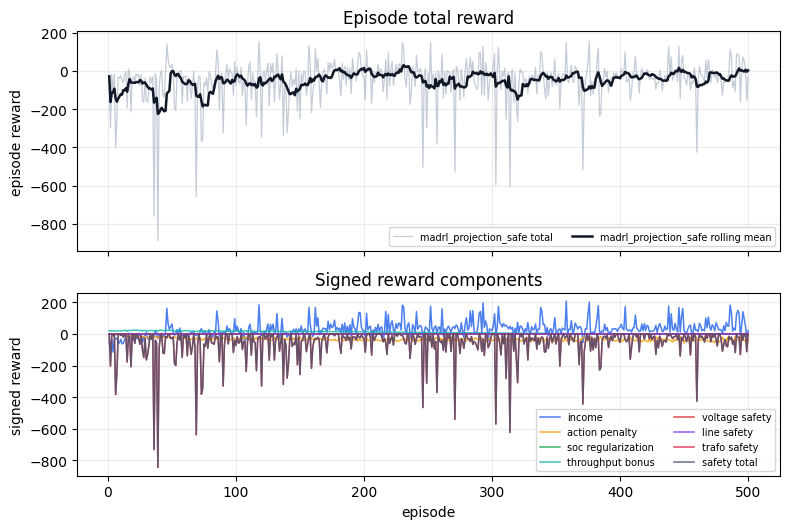

In [4]:
plt.close("all")
figures = plot_madrl_outputs(result, run_dir)
_plot_specs = [
    ("1. 电力电量平衡", "madrl_projection_safe_power_balance"),
    ("2. 电价", "madrl_projection_safe_price"),
    ("3. 总体储能充放功率与 SoC", "madrl_projection_safe_battery_soc"),
    ("4. 电压", "madrl_projection_safe_voltage"),
    ("5. 净负荷", "madrl_projection_safe_net_load"),
    ("6. 训练奖励", "madrl_projection_safe_learning_curve"),
]
for title, name in _plot_specs:
    print(title)
    display(figures[name])
    plt.close(figures[name])
